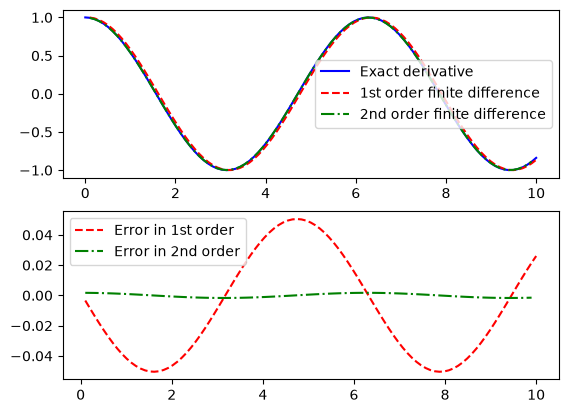

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 

x = np.linspace(0, 10, 100)
fx = np.sin(x)
dfdx_exact = np.cos(x)
dfxdx_1st = np.append(np.nan, np.diff(fx) / np.diff(x))
dfxdx_2nd = np.zeros_like(fx) * np.nan
dfxdx_2nd[1:-1] = (fx[2:] - fx[:-2])/(x[2:] - x[:-2])
fig,ax = plt.subplots(2)
ax[0].plot(x, dfdx_exact, label='Exact derivative', color='blue')
ax[0].plot(x, dfxdx_1st, label='1st order finite difference', color='red', linestyle='--')
ax[0].plot(x, dfxdx_2nd, label='2nd order finite difference', color='green', linestyle='-.')
ax[1].plot(x, dfdx_exact - dfxdx_1st, label='Error in 1st order', color='red', linestyle='--')
ax[1].plot(x, dfdx_exact - dfxdx_2nd, label='Error in 2nd order', color='green', linestyle='-.')
ax[0].legend()
ax[1].legend()  

In [2]:
import h5py

with h5py.File("difference_scheme_results.h5", "w") as results:
    results.attrs["function"] = "sin(x)"
    results.attrs["derivative"] = "cos(x)"
    results.create_dataset("x", data=x)
    results.create_dataset("f", data=fx)
    results.create_dataset("exact_derivative", data=dfdx_exact)
    results.create_dataset("first_order_derivative", data=dfxdx_1st)
    results.create_dataset("second_order_derivative", data=dfxdx_2nd)
    results.create_dataset("first_order_error", data=dfdx_exact - dfxdx_1st)
    results.create_dataset("second_order_error", data=dfdx_exact - dfxdx_2nd)

print("Wrote difference_scheme_results.h5")

Wrote difference_scheme_results.h5


$f(x+\Delta x) = f(x) + \int_x^{x+\Delta x} f'(x)\, \mathrm{d} x = f(x) + \Delta x f'(x) + \mathcal{o}(\Delta x)$

When using the first order approximation, we obtain 
$f'(x)| _\text{num} =  f'(x)|_\text{exact} + \mathcal{o}(\Delta x) / \Delta x$

$f(x+\Delta x) = f(x) + \Delta x f'(x) + \frac{1}{2} f''(x) \Delta x^2  + \mathcal{o}(\Delta x^2)$
When using the second order scheme, we obtain



$$f'(x)| _\text{num} =  f'(x)|_\text{exact} + f''(x) \Delta x+ \mathcal{o}(\Delta x^2) / \Delta x$$